# Max distance by terrain and sensor set

The same terrain x sensor grid as `significant_plot.ipynb`, but in raw metres
rather than normalised score, so the absolute cost of each terrain is visible.
Error bars are the 95% CI of the mean.

Figure geometry and fonts come from `paper_style.py`.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

import paper_data as pdata
from paper_stats import mean_ci
from paper_style import (PAGE, H_SHORT, SENSORS, SENSOR_COLOR, SENSOR_LABEL,
                         TERRAIN_LABEL, grouped_bars, paper_rc, save_figure,
                         style_axes, swatch_legend)

TERRAINS = ["flat", "rough", "morph", "slope10", "slope_10", "mass1000"]

## Load rollouts

In [2]:
runs = pdata.load_terrains(SENSORS, TERRAINS)
print(f"{len(runs)} terrains x {len(SENSORS)} sensor sets x {pdata.N_POLICIES} policies")

6 terrains x 4 sensor sets x 5 policies


## Figure: policy 0

In [3]:
POLICY = 0

distance = {t: pdata.by_sensor(runs[t], policy=POLICY) for t in TERRAINS}
print(f"policy {POLICY}: n={distance['flat']['vel'].size} envs per bar")

means, errors = {}, {}
for t in TERRAINS:
    for s in SENSORS:
        means[(t, s)], errors[(t, s)] = mean_ci(distance[t][s])

for t in TERRAINS:
    for s in SENSORS:
        m, e = means[(t, s)], errors[(t, s)]
        print(f"{TERRAIN_LABEL[t]:<16}{SENSOR_LABEL[s]:<12} "
              f"mean={m:5.2f}  95% CI=[{m - e:5.2f}, {m + e:5.2f}]")

policy 0: n=30 envs per bar
Flat            pos+act      mean= 2.77  95% CI=[ 2.74,  2.79]
Flat            vel          mean= 2.14  95% CI=[ 2.08,  2.19]
Flat            vel+act      mean= 2.40  95% CI=[ 2.37,  2.43]
Flat            pos+vel+act  mean= 2.75  95% CI=[ 2.72,  2.77]
Rough           pos+act      mean= 2.00  95% CI=[ 1.93,  2.08]
Rough           vel          mean= 1.35  95% CI=[ 1.28,  1.42]
Rough           vel+act      mean= 1.67  95% CI=[ 1.62,  1.73]
Rough           pos+vel+act  mean= 1.95  95% CI=[ 1.89,  2.01]
Morph           pos+act      mean= 2.23  95% CI=[ 2.16,  2.31]
Morph           vel          mean= 1.95  95% CI=[ 1.89,  2.01]
Morph           vel+act      mean= 1.89  95% CI=[ 1.82,  1.97]
Morph           pos+vel+act  mean= 2.10  95% CI=[ 2.04,  2.16]
Slope Downhill  pos+act      mean= 3.22  95% CI=[ 3.20,  3.24]
Slope Downhill  vel          mean= 2.59  95% CI=[ 2.55,  2.62]
Slope Downhill  vel+act      mean= 2.90  95% CI=[ 2.88,  2.93]
Slope Downhill  pos+vel+act

Saved -> local_prop_max_distance_by_terrain_policy0.pdf, local_prop_max_distance_by_terrain_policy0.png


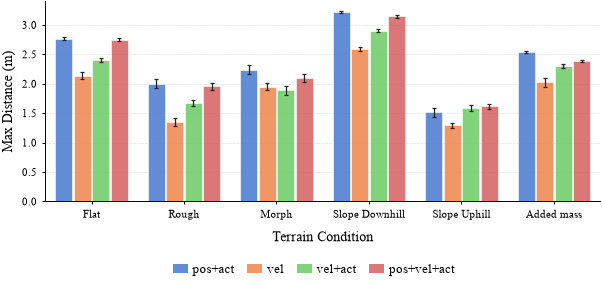

In [4]:
with paper_rc():
    fig, ax = plt.subplots(figsize=(PAGE, H_SHORT))

    grouped_bars(ax, TERRAINS, SENSORS, means, errors,
                 colors=[SENSOR_COLOR[s] for s in SENSORS])

    ax.set_xticks(range(len(TERRAINS)))
    ax.set_xticklabels([TERRAIN_LABEL[t] for t in TERRAINS])
    ax.set_xlabel("Terrain Condition", labelpad=8)
    ax.set_ylabel("Max Distance (m)", labelpad=5)
    ax.set_xlim(-0.5, len(TERRAINS) - 0.5)
    style_axes(ax)

    swatch_legend(fig, [SENSOR_LABEL[s] for s in SENSORS],
                  [SENSOR_COLOR[s] for s in SENSORS])

    save_figure(fig, f"local_prop_max_distance_by_terrain_policy{POLICY}")
    plt.show()